In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import scipy.integrate as scint
import scipy.optimize as scopt

In [12]:
# Importing growth data
tf_i = 72
OD_data = pd.read_csv("expt_growth_data.csv")
time = OD_data["time(min)"].to_numpy()[:tf_i]
OD_blank = 0.078
D1 = OD_data["D1"].to_numpy()[:tf_i] - OD_blank
D2 = OD_data["D2"].to_numpy()[:tf_i] - OD_blank
D3 = OD_data["D3"].to_numpy()[:tf_i] - OD_blank
D4 = OD_data["D4"].to_numpy()[:tf_i] - OD_blank
B1 = OD_data["B1"].to_numpy()[:tf_i] - OD_blank
B2 = OD_data["B2"].to_numpy()[:tf_i] - OD_blank
B3 = OD_data["B3"].to_numpy()[:tf_i] - OD_blank

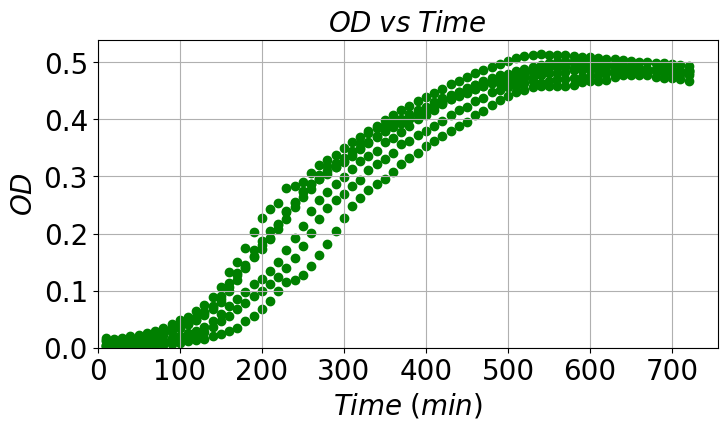

In [13]:
# Plot raw OD data
fig, ax = plt.subplots(1, 1, figsize=(8, 4), sharex='col')
for dataset in [D1, D2, D3, D4, B1, B2, B3]:
    ax.scatter(time, dataset, label='Experiment', color='green')
ax.set_xlabel('$Time \; (min)$', fontsize=20)
ax.set_ylabel(r'$OD$', fontsize=20)
ax.set_title(r'$OD \; vs \; Time$', fontsize=20)
ax.set_xlim(0)
ax.set_ylim(0)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.grid(True)

In [14]:
# Convert OD to cell concentration
C_OD = 1e9
C1 = D1 * C_OD
C2 = D2 * C_OD
C3 = D3 * C_OD
C4 = D4 * C_OD
C5 = B1 * C_OD
C6 = B2 * C_OD
C7 = B3 * C_OD

C_av = (C1 + C2 + C3 + C4 + C5 + C6 + C7) / 7
C_max = np.max(C_av)

In [15]:
# Initial and max values
C_list = [C1, C2, C3, C4, C5, C6, C7]
C0_list = [np.min(C) for C in C_list]
Cmax_list = [np.max(C) for C in C_list]

In [16]:
def log_growth(c, t, k_gr, C_max):
    return k_gr * c * (1 - c / C_max)

def growth_error(p):
    error = 0
    for i, (C, k_gr) in enumerate(zip(C_list, p)):
        C0 = np.min(C)
        Cmax = np.max(C)
        sol = scint.odeint(log_growth, C0, time, args=(k_gr, Cmax), hmax=10, rtol=1e-4).flatten()
        error += np.sum((sol - C)**2)
    return error

In [17]:
# Optimization
p0 = np.array([0.009]*7)
sol = scopt.minimize(growth_error, p0, method='nelder-mead')
k_gr_values = sol.x
k_gr_values

array([0.01481465, 0.01493478, 0.01493515, 0.01885024, 0.01739013,
       0.01886247, 0.01667254])

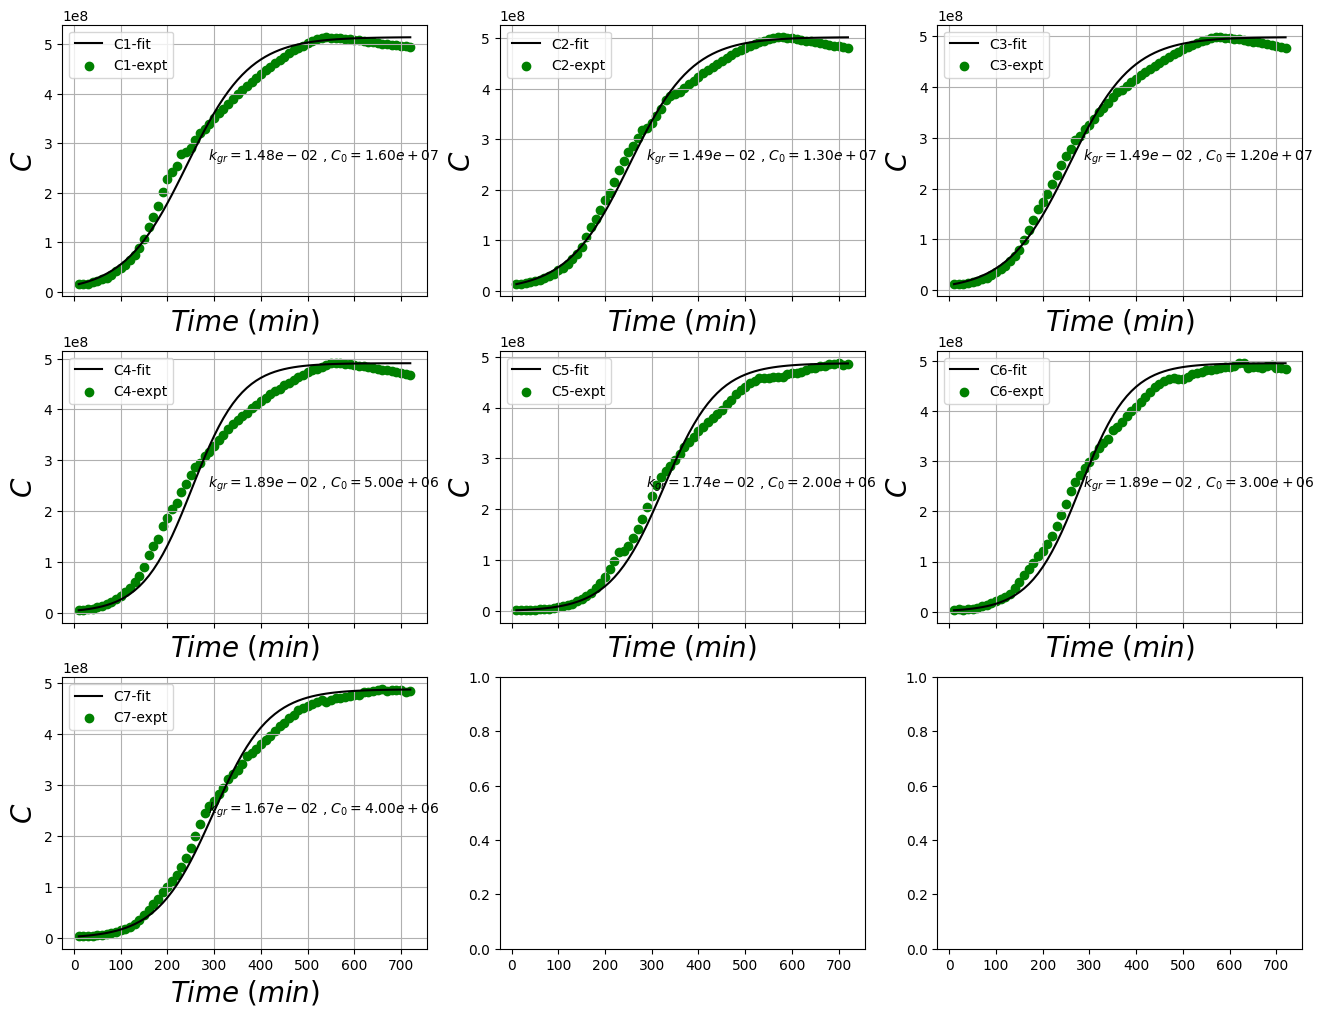

In [18]:
# Plot fits
fig, ax = plt.subplots(3, 3, figsize=(16, 12), sharex='col')
xy = (0.4, 0.5)

for i, (C, k_gr, C0, Cmax) in enumerate(zip(C_list, k_gr_values, C0_list, Cmax_list)):
    r, c = divmod(i, 3)
    sol = scint.odeint(log_growth, C0, time, args=(k_gr, Cmax), hmax=10, rtol=1e-4).flatten()
    ax[r][c].plot(time, sol, label=f'C{i+1}-fit', color='black')
    ax[r][c].scatter(time, C, label=f'C{i+1}-expt', color='green')
    ax[r][c].set_xlabel('$Time \; (min)$', fontsize=20)
    ax[r][c].set_ylabel(r'$C$', fontsize=20)
    text = rf"$k_{{gr}} = {k_gr:.2e}$ , $C_0 = {C0:.2e}$"
    ax[r][c].annotate(text, xy=xy, xytext=xy, textcoords='axes fraction')
    ax[r][c].grid(True)
    ax[r][c].legend()